# Continuation
We have seen how to implement RL using Monte Carlo Control, Now lets look at some other approximation approaches like Temporal Difference learning (TD Learning) and Q Learning. We will also look at a an implementating of the famous Double-Q Learning.

## Motivation

The main idea behind On-policy **Temporal Difference Learning** (Also known as **SARSA**) is that we will update our Q_Table after every step, not after the episode completes. And by updating our Q-Table every step, our agent will start taking the next step more precisely - with better estimates of Action Value. By using TD Learning, we expect our agent to start showing "intelligence" even in the very first episode - unlike our Monte Carlo Agent, which only starts updating its "intelligence" after an episode ends. Here are the Key Differences:

| Property | Monte Carlo Control | SARSA (Temporal Difference Control) |
| :--- | :--- | :--- |
| **Bias** | **Zero Bias.** It updates using real, unadulterated returns from the environment. | **High Bias.** Early on, it updates its table using guesses based on other unlearned guesses. |
| **Variance** | **High Variance.** Every random exploration choice throughout a long episode dramatically changes $G_t$. | **Low Variance.** Updates are bounded by a single step transition ($R_{t+1}$ and the next immediate state). |
| **Data Efficiency** | **Slow.** Requires complete trajectories; bad choices early on can ruin an entire episode's learning potential. | **Fast.** Learns continuously from individual transitions; highly effective in long or infinite horizons. |

## Temporal Differnece Learning

There are many flavours of Temporal Difference Learning. The most popular one being the Temporal Difference Zero or TD-0 for short. It has an update Equation very similar to Monte Carlo Method.

### Temporal Differrence Learning Zero (TD(0))

Lets Look at Temporal Difference learning with 1 step Lookahead.
Update Equation:

$$
Q_{t+1}(s_t,a_t) \leftarrow Q_t(s_t,a_t) + \alpha (R_{t+1} + \gamma (Q_t(s_{t+1}, a_{t+1})) - Q_t(s_t, a_t)  )
$$

Here:
- $Q_t$: Q-Table at time t
- $Q_{t+1}$:Q-Table at time t + 1
- $s_t$: State at time t (Current State)
- $s_{t+1}$ : State at time t+1 (Next State)
- $a_t$: Action at time t (Current Action)
- $a_{t+1}$ : Action at time t+1 (Next Action)
- $R_{t+1}$: Reward agent got for taking the step
- $\alpha$ : Learning Rate
- $\gamma$: Discount Factor


### 2-Steps Lookahead
The TD(0) algorithm can also be used for 2 step lookahead. The Equation would then be:


$$Q_{t+1}(s_t,a_t) \leftarrow Q_t(s_t,a_t) + \alpha ( R_{t+1} + \gamma R_{t+2} + \gamma^2 Q(S_{t+2}, A_{t+2}) - Q_t(s_t, a_t))  $$

Note that the only thing that changed here was the return value. We are taking into account 2 rewards instead of only  $R_{t+1}$ and we are taking estimate of the state our agent ends up in after taking 2 steps, ie, $Q(S_{t+2}, A_{t+2})$.


### N-Step Lookahead 

Similarly, we can generalise this idea to to a variable, N - performing N steps then taking the estimate. The equation would then be:


$$Q_{t+1}(s_t,a_t) \leftarrow Q_t(s_t,a_t) + \alpha ( \sum_{k=1}^{N} \gamma^{k-1} R_{t+k} + \gamma^N Q(S_{t+N}, A_{t+N}) - Q_t(s_t, a_t))  $$


Notice that if N is same as the termination step ($n \rightarrow \infty$), our equation will essentially become identical to the Monte Carlo Control Algorithm.


### Code Section

#### Initialzie

In [1]:
#Importing Libraries
import gymnasium as gym
import numpy as np
from datetime import datetime
from utils import *

# Constants and Hyperparameters
epsilon = 0.1
epsilon_decay_rate = 0.999
epsilon_min = 0.01

gamma = 0.9
alpha = 0.1
num_episodes = 5000
MAX_STEPS_PER_EPISODE = 500

seed = 42
rng = np.random.default_rng(seed)

env = gym.make("CliffWalking-v1", max_episode_steps=MAX_STEPS_PER_EPISODE)

action_space = np.arange(env.action_space.n)
observation_space = np.arange(env.observation_space.n)

q_table = np.zeros((len(observation_space), len(action_space)))
episode_lengths = []
episode_rewards = []
episode_durations = []
episode_avg_td_error = [] #Instead of MC Error, we will track the average TD error per episode

/Users/tahsinhasemaonim/.local/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:

def choose_action(state, epsilon):
    if rng.random() < epsilon:
        return rng.choice(action_space)
    else:
        return np.argmax(q_table[state])



for episode in range(num_episodes):
    state, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    episode_reward = 0
    episode_data = [] # To store (state, action, reward, next_state) for TD error calculation
    start_time = datetime.now()

    epsilon = max(epsilon * epsilon_decay_rate, epsilon_min)

    action = choose_action(state, epsilon)
    td_errors_in_episode = [] # To track TD errors for the current episode

    while not (terminated or truncated):

        next_state, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        # Store the transition for TD error calculation
        episode_data.append((state, action, reward, next_state))

        if (terminated or truncated):
            td_target = reward  # No next state value if episode has ended
            next_action = None  # No next action if episode has ended
        else:
            next_action = choose_action(next_state, epsilon)
            td_target = reward + gamma * q_table[next_state, next_action]

        td_error = td_target - q_table[state][action]
        q_table[state, action] += alpha * td_error


        td_errors_in_episode.append(abs(td_error))

        state = next_state
        action = next_action


    end_time = datetime.now()
    episode_lengths.append(len(episode_data))
    episode_rewards.append(episode_reward)
    episode_durations.append((end_time - start_time).total_seconds())

    # Calculate average TD error for the episode
    avg_td_error = np.mean(td_errors_in_episode)
    episode_avg_td_error.append(avg_td_error)
    if (episode + 1) % 500 == 0:
        print(f"Episode {episode + 1}/{num_episodes} - Total Reward: {episode_reward}, Length: {len(episode_data)}, Duration: {(end_time - start_time).total_seconds():.2f}s, Avg TD Error: {avg_td_error:.4f}")




Episode 500/5000 - Total Reward: -15, Length: 15, Duration: 0.00s, Avg TD Error: 0.0420
Episode 1000/5000 - Total Reward: -17, Length: 17, Duration: 0.00s, Avg TD Error: 0.0075
Episode 1500/5000 - Total Reward: -17, Length: 17, Duration: 0.00s, Avg TD Error: 0.0063
Episode 2000/5000 - Total Reward: -15, Length: 15, Duration: 0.00s, Avg TD Error: 0.0110
Episode 2500/5000 - Total Reward: -15, Length: 15, Duration: 0.00s, Avg TD Error: 0.0062
Episode 3000/5000 - Total Reward: -17, Length: 17, Duration: 0.00s, Avg TD Error: 0.0891
Episode 3500/5000 - Total Reward: -15, Length: 15, Duration: 0.00s, Avg TD Error: 0.0067
Episode 4000/5000 - Total Reward: -15, Length: 15, Duration: 0.00s, Avg TD Error: 0.0047
Episode 4500/5000 - Total Reward: -15, Length: 15, Duration: 0.00s, Avg TD Error: 0.0095
Episode 5000/5000 - Total Reward: -15, Length: 15, Duration: 0.00s, Avg TD Error: 0.0180


#### Simulate

In [3]:
policy = lambda state: np.argmax(q_table[state])

visualize_policy(policy_fn=policy, title="One Step TD Zero")


 Starting Evaluation: One Step TD Zero
Step=  1 | State=24 | Reward=  -1 | Total Reward=  -1 | Action=Up
Step=  2 | State=12 | Reward=  -1 | Total Reward=  -2 | Action=Up
Step=  3 | State=13 | Reward=  -1 | Total Reward=  -3 | Action=Right
Step=  4 | State=14 | Reward=  -1 | Total Reward=  -4 | Action=Right
Step=  5 | State=15 | Reward=  -1 | Total Reward=  -5 | Action=Right
Step=  6 | State=16 | Reward=  -1 | Total Reward=  -6 | Action=Right
Step=  7 | State=17 | Reward=  -1 | Total Reward=  -7 | Action=Right
Step=  8 | State=18 | Reward=  -1 | Total Reward=  -8 | Action=Right
Step=  9 | State=19 | Reward=  -1 | Total Reward=  -9 | Action=Right
Step= 10 | State=20 | Reward=  -1 | Total Reward= -10 | Action=Right
Step= 11 | State=21 | Reward=  -1 | Total Reward= -11 | Action=Right
Step= 12 | State=22 | Reward=  -1 | Total Reward= -12 | Action=Right
Step= 13 | State=34 | Reward=  -1 | Total Reward= -13 | Action=Down
Step= 14 | State=35 | Reward=  -1 | Total Reward= -14 | Action=Right
S


Agent Learning Summary:
  - Final Average TD Error per Episode: 0.0180
  - Total Episodes: 5000
  - Best Episode Reward: -15
  - Worst Episode Reward: -1,589
  - Average Episode Length: 17.77
  - Average Episode Duration: 0.00
  - Convergence Status: Converged in 233 (Threshold: 0.05)


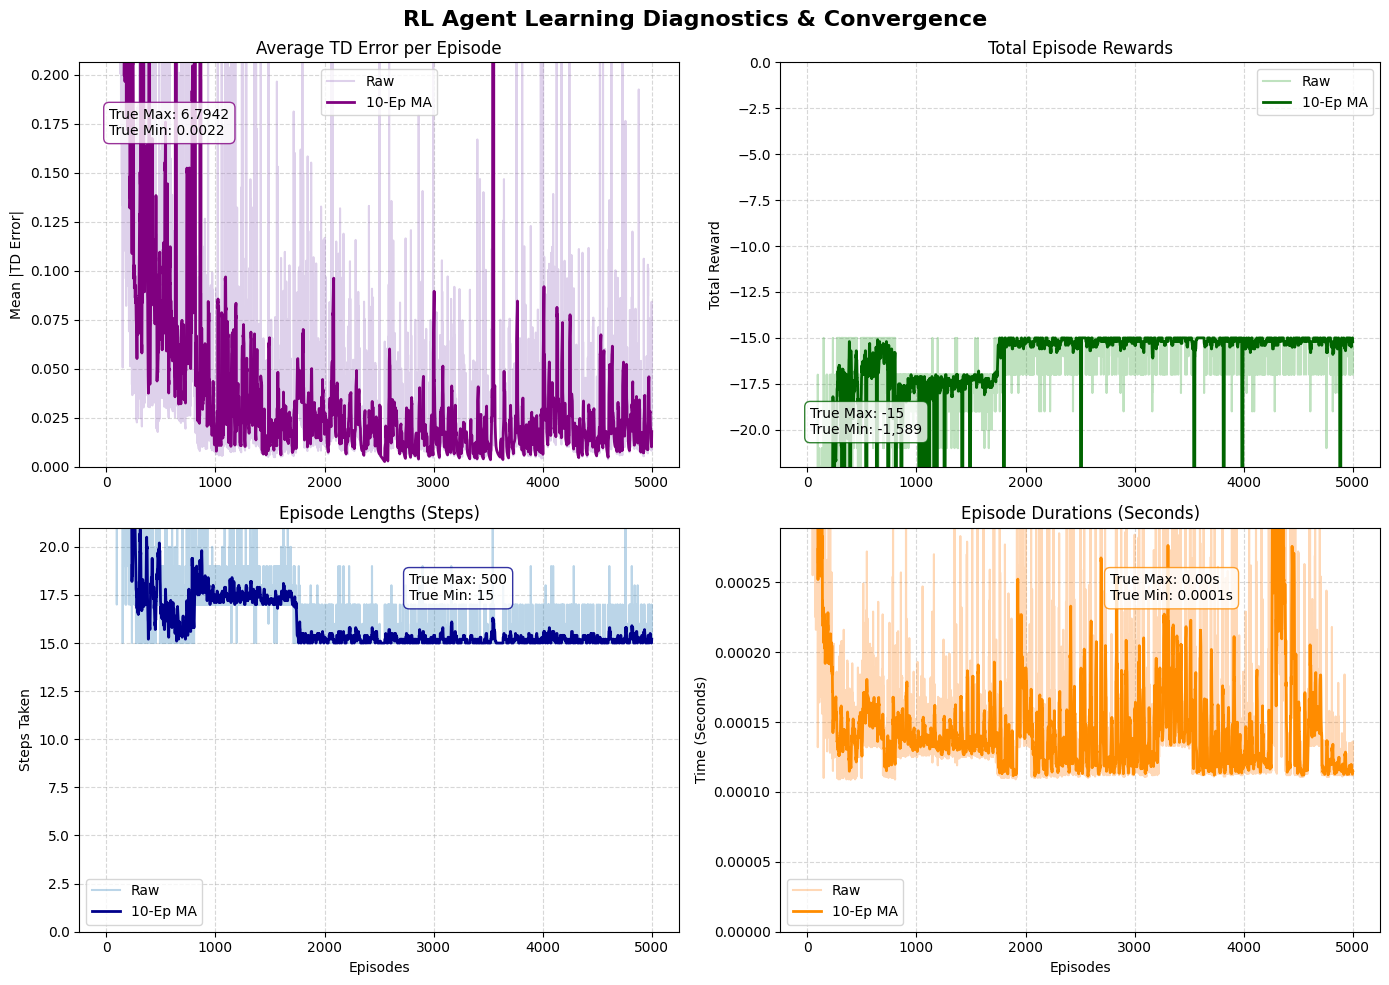

In [4]:
from utils import *


plot_smooth_graphs(errors=episode_avg_td_error, episode_rewards=(episode_rewards), episode_lengths=(episode_lengths),
            episode_durations=(episode_durations), error_title="Average TD Error per Episode", error_ylabel="Mean |TD Error|", 
            convergence_threshold=0.05)

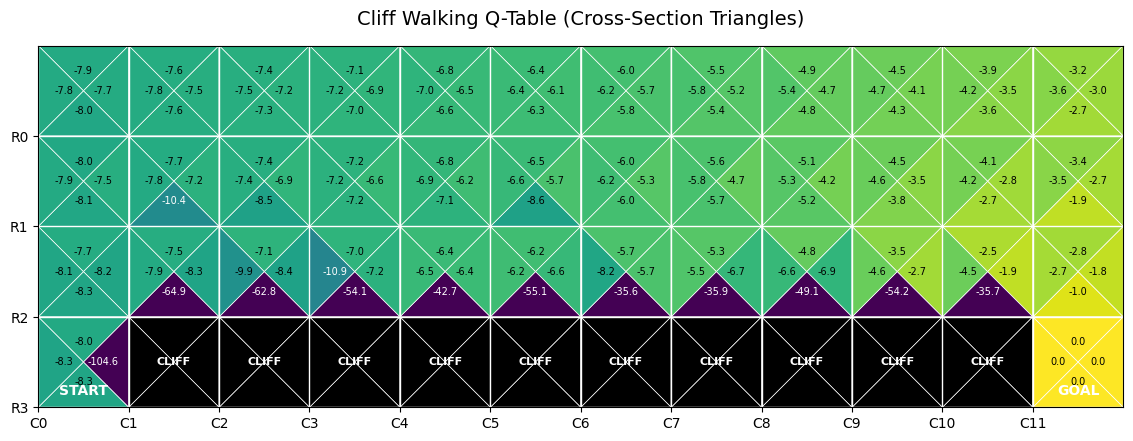

In [5]:
plot_q_table(q_table=q_table)

### 2-Step TD Return

It'd be an interesting exercise to also illustrate the use of 2-step return instead of a one step TD return. As mentioned previously, the Update equation for that would be:

$$. Q_{t+1}(s_t,a_t) \leftarrow Q_t(s_t,a_t) + \alpha ( R_{t+1} + \gamma R_{t+2} + \gamma^2 Q(S_{t+2}, A_{t+2}) - Q_t(s_t, a_t))  $$


Where
- $TD_{target} = R_{t+1} + \gamma R_{t+2} + \gamma^2 Q(S_{t+2}, A_{t+2})$
- $TD_{error} =  R_{t+1} + \gamma R_{t+2} + \gamma^2 Q(S_{t+2}, A_{t+2}) - Q_t(s_t, a_t)$

Simplified Equation would be:

$$
Q_{t+1}(s_t,a_t) \leftarrow Q_t(s_t,a_t) + \alpha (TD_{error})
$$




In [6]:

import gymnasium as gym
import numpy as np
from datetime import datetime
from utils import *

# ------------------------------- Constants and Hyperparameters ------------------------------- #
epsilon = 0.1
epsilon_decay_rate = 0.999
epsilon_min = 0.01

gamma = 0.9
alpha = 0.1
num_episodes = 5000
MAX_STEPS_PER_EPISODE = 500

seed = 42
rng = np.random.default_rng(seed)

env = gym.make("CliffWalking-v1", max_episode_steps=MAX_STEPS_PER_EPISODE)

action_space = np.arange(env.action_space.n)
observation_space = np.arange(env.observation_space.n)

q_table = np.zeros((len(observation_space), len(action_space)))
episode_lengths = []
episode_rewards = []
episode_durations = []
episode_avg_td_error = [] 

def choose_action(state, epsilon):
    if rng.random() < epsilon:
        return rng.choice(action_space)
    else:
        return np.argmax(q_table[state])
    


# ------------------------------- Episode Itternation ------------------------------- #

for episode in range(num_episodes):
    state, info = env.reset(seed=seed)

    start_time = datetime.now()
    terminated = False
    truncated = False
    episode_reward = 0
    epsilon = max(epsilon * epsilon_decay_rate, epsilon_min)

    
    td_errors_in_episode = []
    states = [state]
    action = choose_action(state, epsilon)
    actions = [action] # Initial action
    rewards = []
    
    step_num = 0
    while True:
        next_state, reward, terminated, truncated, info = env.step(action)

        rewards.append(reward)
        episode_reward += reward
        states.append(next_state)

        # ------------------- Handle Terminal States First (Episode ends) ------------------- #
        # Note: If its a terminal state, we should not choose a next action. So handle terminal state first.

        if terminated or truncated:
            
            # ------------------- Pen-Ultimate Step ------------------- #
            t = len(rewards) - 2
            if t >= 0: ## Check if tere are at least 2 rewards in array. t is negative only if len(rewards) < 2.
                td_target = rewards[t] + gamma * rewards[t+1]
                td_error = td_target - q_table[states[t], actions[t]]

                q_table[states[t], actions[t]] += alpha * td_error
                td_errors_in_episode.append(abs(td_error))



            # ------------------- Ultimate Step ------------------- #
            t = len(rewards) - 1
            if t >= 0: ## Check if tere are at least 1 rewards in array. t is negative only if len(rewards) < 1.
                td_target = rewards[t]
                td_error = td_target - q_table[states[t], actions[t]]

                q_table[states[t], actions[t]] += alpha * td_error
                td_errors_in_episode.append(abs(td_error))

            break


        # ---------------------------- Key Ideas ---------------------------- #
        # Not Terminal states, so we sample an action to take. At this point out arrrays will have:
        # r -> [r_0...r_t]
        # s -> [s_1...s_t, s_t+1]
        # a -> [a_0...a_t, a_t+1]
        # ------------------------------------------------------------------- #


        next_action = choose_action(next_state, epsilon)
        actions.append(next_action)
        action = next_action
        assert len(states), len(actions)



        # ---------------------------- Main Update Equation ---------------------------- #
        if len(rewards) >= 2:
            t = len(rewards) - 2
            assert t >= 0

            td_target = rewards[t] + gamma * rewards[t+1] + (gamma ** 2) * q_table[states[t+2], actions[t+2]]
            td_error = td_target - q_table[states[t], actions[t]]
            q_table[states[t], actions[t]]  += alpha * td_error

            td_errors_in_episode.append(abs(td_error))
            
        step_num+=1



    end_time = datetime.now()
    episode_lengths.append(step_num)
    episode_rewards.append(episode_reward)
    episode_durations.append((end_time - start_time).total_seconds())

    # Calculate average TD error for the episode
    avg_td_error = np.mean(td_errors_in_episode)
    episode_avg_td_error.append(avg_td_error)
    if (episode + 1) % 500 == 0:
        print(f"Episode {episode + 1}/{num_episodes} - Total Reward: {episode_reward}, Length: {episode_lengths[episode]}, Duration: {(end_time - start_time).total_seconds():.2f}s, Avg TD Error: {avg_td_error:.4f}", "Epsilon", epsilon)

env.close()


Episode 500/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0741 Epsilon 0.060637894486118574
Episode 1000/5000 - Total Reward: -19, Length: 18, Duration: 0.00s, Avg TD Error: 0.2380 Epsilon 0.03676954247709642
Episode 1500/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0467 Epsilon 0.022296276370290302
Episode 2000/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0232 Epsilon 0.01351999253975
Episode 2500/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0177 Epsilon 0.01
Episode 3000/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0108 Epsilon 0.01
Episode 3500/5000 - Total Reward: -15, Length: 14, Duration: 0.00s, Avg TD Error: 0.0128 Epsilon 0.01
Episode 4000/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0053 Epsilon 0.01
Episode 4500/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0056 Epsilon 0.01
Episode 5000/5000 - Tota


Agent Learning Summary:
  - Final Avg. Update Error: 0.0222
  - Total Episodes: 5000
  - Best Episode Reward: -15
  - Worst Episode Reward: -1,391
  - Average Episode Length: 17.26
  - Average Episode Duration: 0.00
  - Convergence Status: Not Converged (Threshold: 0.001)


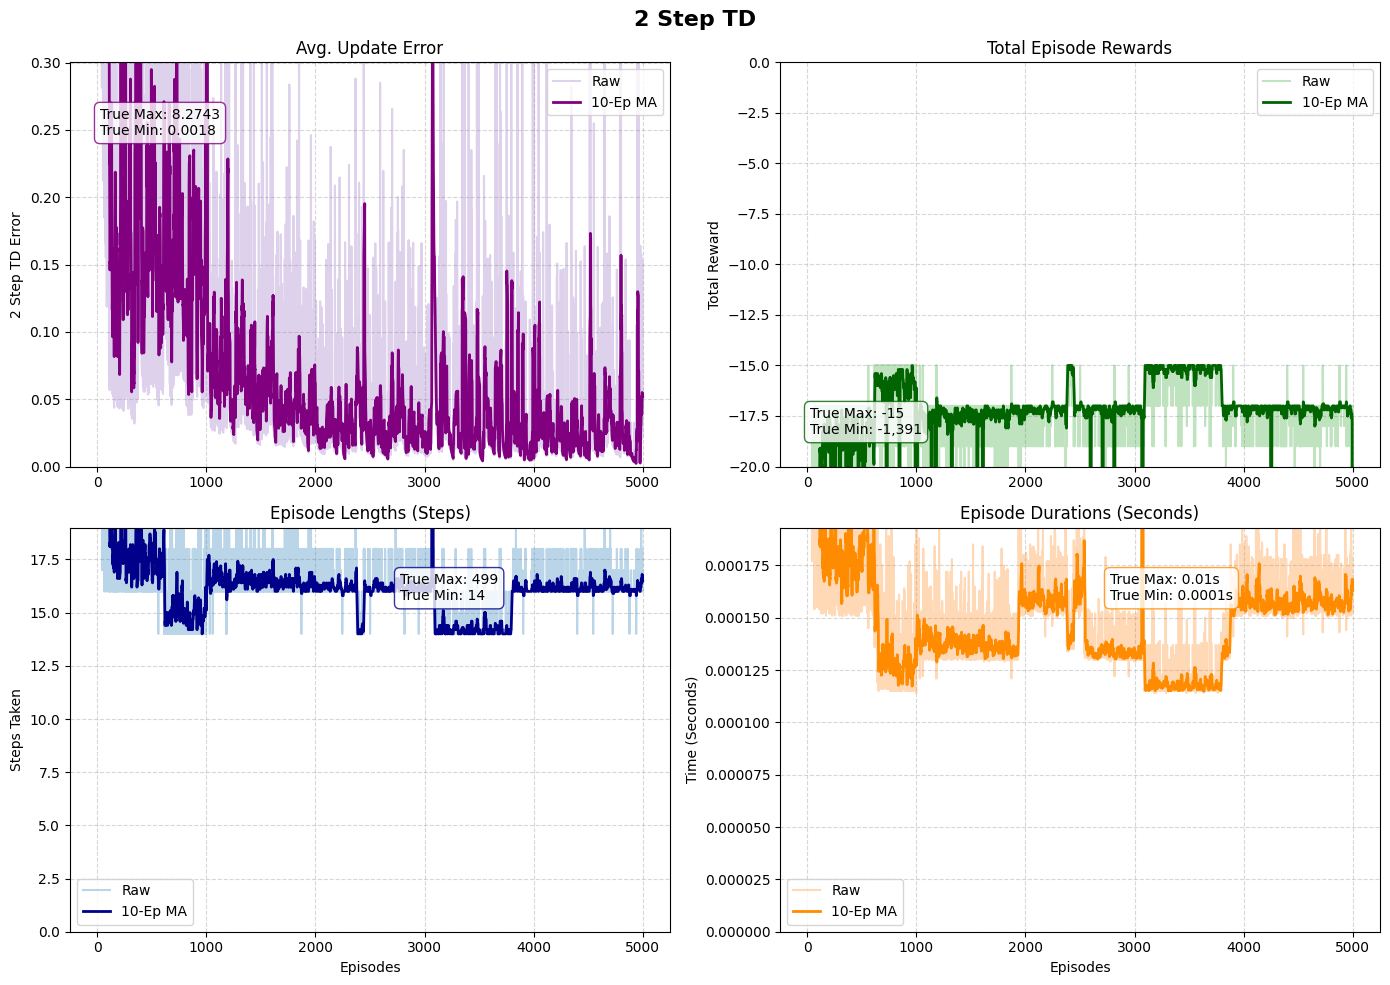

In [7]:
policy = lambda state : np.argmax(q_table[state])

plot_smooth_graphs(
    episode_avg_td_error,
    episode_rewards=episode_rewards,
    episode_durations=episode_durations,
    episode_lengths=episode_lengths,
    title="2 Step TD",
    error_ylabel="2 Step TD Error"
)


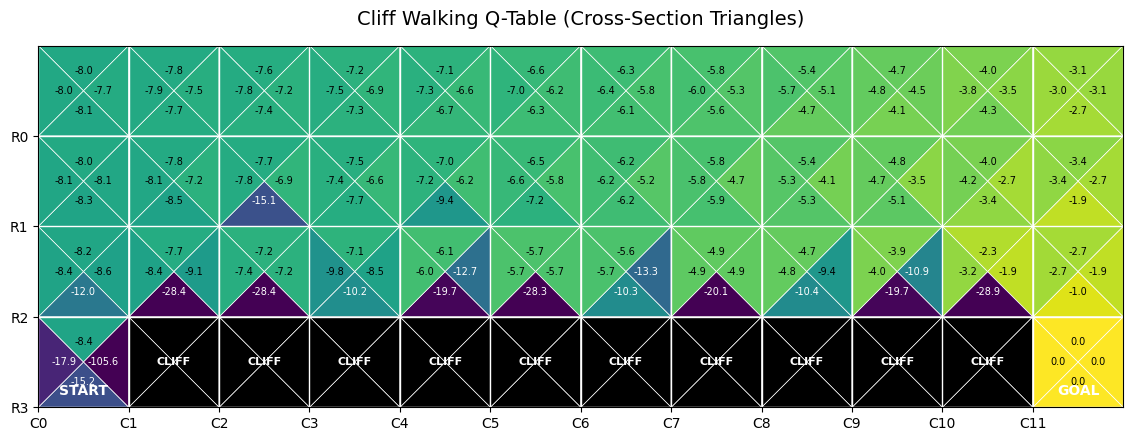

In [8]:
from utils import plot_q_table

plot_q_table(q_table)

In [9]:
from utils import visualize_policy

policy = lambda state: np.argmax(q_table[state])

visualize_policy(policy_fn=policy)


 Starting Evaluation: RL Agent
Step=  1 | State=24 | Reward=  -1 | Total Reward=  -1 | Action=Up
Step=  2 | State=12 | Reward=  -1 | Total Reward=  -2 | Action=Up
Step=  3 | State= 0 | Reward=  -1 | Total Reward=  -3 | Action=Up
Step=  4 | State= 1 | Reward=  -1 | Total Reward=  -4 | Action=Right
Step=  5 | State= 2 | Reward=  -1 | Total Reward=  -5 | Action=Right
Step=  6 | State= 3 | Reward=  -1 | Total Reward=  -6 | Action=Right
Step=  7 | State= 4 | Reward=  -1 | Total Reward=  -7 | Action=Right
Step=  8 | State= 5 | Reward=  -1 | Total Reward=  -8 | Action=Right
Step=  9 | State= 6 | Reward=  -1 | Total Reward=  -9 | Action=Right
Step= 10 | State= 7 | Reward=  -1 | Total Reward= -10 | Action=Right
Step= 11 | State= 8 | Reward=  -1 | Total Reward= -11 | Action=Right
Step= 12 | State=20 | Reward=  -1 | Total Reward= -12 | Action=Down
Step= 13 | State=21 | Reward=  -1 | Total Reward= -13 | Action=Right
Step= 14 | State=22 | Reward=  -1 | Total Reward= -14 | Action=Right
Step= 15 | S

### N-Step TD Return

Similarly, we can implement an N step version of the On-Policy TD Control. The update equation would be:


$$Q_{t+1}(s_t,a_t) \leftarrow Q_t(s_t,a_t) + \alpha ( \sum_{k=1}^{N} \gamma^{k-1} R_{t+k} + \gamma^N Q(S_{t+N}, A_{t+N}) - Q_t(s_t, a_t))  $$

Notice the $TD_{target}$ now is $\sum_{k=1}^{N} \gamma^{k-1} R_{t+k} + \gamma^N Q(S_{t+N}, A_{t+N}) $


Lets take a look at the code:

In [10]:
import gymnasium as gym
import numpy as np
from datetime import datetime
from utils import *

# ------------------------------- Constants and Hyperparameters ------------------------------- #
epsilon = 0.1
epsilon_decay_rate = 0.999
epsilon_min = 0.01

gamma = 0.9
alpha = 0.1
num_episodes = 5000
MAX_STEPS_PER_EPISODE = 500

seed = 42
rng = np.random.default_rng(seed)

env = gym.make("CliffWalking-v1", max_episode_steps=MAX_STEPS_PER_EPISODE)

action_space = np.arange(env.action_space.n)
observation_space = np.arange(env.observation_space.n)

q_table = np.zeros((len(observation_space), len(action_space)))
episode_lengths = []
episode_rewards = []
episode_durations = []
episode_avg_td_error = [] 

def choose_action(state, epsilon):
    if rng.random() < epsilon:
        return rng.choice(action_space)
    else:
        return np.argmax(q_table[state])
    


# ------------------------------- Episode Itternation ------------------------------- #

for episode in range(num_episodes):
    state, info = env.reset(seed=seed)

    start_time = datetime.now()
    terminated = False
    truncated = False
    episode_reward = 0
    epsilon = max(epsilon * epsilon_decay_rate, epsilon_min)

    
    td_errors_in_episode = []
    states = [state]
    action = choose_action(state, epsilon)
    actions = [action] # Initial action
    rewards = []
    

    # ------------------- Choose N-Step ------------------- #
    N_step = 4
    LAMBDA = 0
    #------------------------------------------------------ #

    step_num = 0
    while True:
        next_state, reward, terminated, truncated, info = env.step(action)

        rewards.append(reward)
        episode_reward += reward
        states.append(next_state)

        # ------------------- Handle Terminal States First (Episode ends) ------------------- #
        # Note: If its a terminal state, we should not choose a next action. So handle terminal state first.

        if terminated or truncated:


            # ------------------- Handle all terminal States itteratively ------------------- #
            T = len(rewards)
            t = T - N_step
            while t < T:

                td_target = 0
                for k in range(T - t):
                    td_target += gamma ** (k) * rewards[t+k]
                td_error = td_target - q_table[states[t], actions[t]]
                q_table[states[t], actions[t]] += alpha * td_error
                td_errors_in_episode.append(abs(td_error))

                t += 1

            break



        next_action = choose_action(next_state, epsilon)
        actions.append(next_action)
        action = next_action
        assert len(states), len(actions)


        # ---------------------------- Main Update Equation ---------------------------- #
        if len(rewards) >= N_step:
            t = len(rewards) - N_step

            td_target = 0
            for k in range(N_step):
                td_target += gamma ** (k) * rewards[t+k]

            td_target += gamma ** (N_step) * q_table[states[t+N_step], actions[t+N_step]]
            td_error = td_target - q_table[states[t], actions[t]]
            q_table[states[t], actions[t]]  += alpha * td_error

            td_errors_in_episode.append(abs(td_error))
            
        step_num+=1



    end_time = datetime.now()
    episode_lengths.append(step_num)
    episode_rewards.append(episode_reward)
    episode_durations.append((end_time - start_time).total_seconds())

    # Calculate average TD error for the episode
    avg_td_error = np.mean(td_errors_in_episode)
    episode_avg_td_error.append(avg_td_error)
    if (episode + 1) % 500 == 0:
        print(f"Episode {episode + 1}/{num_episodes} - Total Reward: {episode_reward}, Length: {episode_lengths[episode]}, Duration: {(end_time - start_time).total_seconds():.2f}s, Avg TD Error: {avg_td_error:.4f}", "Epsilon", epsilon)

env.close()

Episode 500/5000 - Total Reward: -19, Length: 18, Duration: 0.00s, Avg TD Error: 0.1778 Epsilon 0.060637894486118574
Episode 1000/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.1368 Epsilon 0.03676954247709642
Episode 1500/5000 - Total Reward: -18, Length: 17, Duration: 0.00s, Avg TD Error: 0.1603 Epsilon 0.022296276370290302
Episode 2000/5000 - Total Reward: -19, Length: 18, Duration: 0.00s, Avg TD Error: 0.0982 Epsilon 0.01351999253975
Episode 2500/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0316 Epsilon 0.01
Episode 3000/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0067 Epsilon 0.01
Episode 3500/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0379 Epsilon 0.01
Episode 4000/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0298 Epsilon 0.01
Episode 4500/5000 - Total Reward: -17, Length: 16, Duration: 0.00s, Avg TD Error: 0.0105 Epsilon 0.01
Episode 5000/5000 - Tota


Agent Learning Summary:
  - Final Avg. Update Error: 0.0201
  - Total Episodes: 5000
  - Best Episode Reward: -17
  - Worst Episode Reward: -1,787
  - Average Episode Length: 19.12
  - Average Episode Duration: 0.00
  - Convergence Status: Converged in 2146 (Threshold: 0.001)


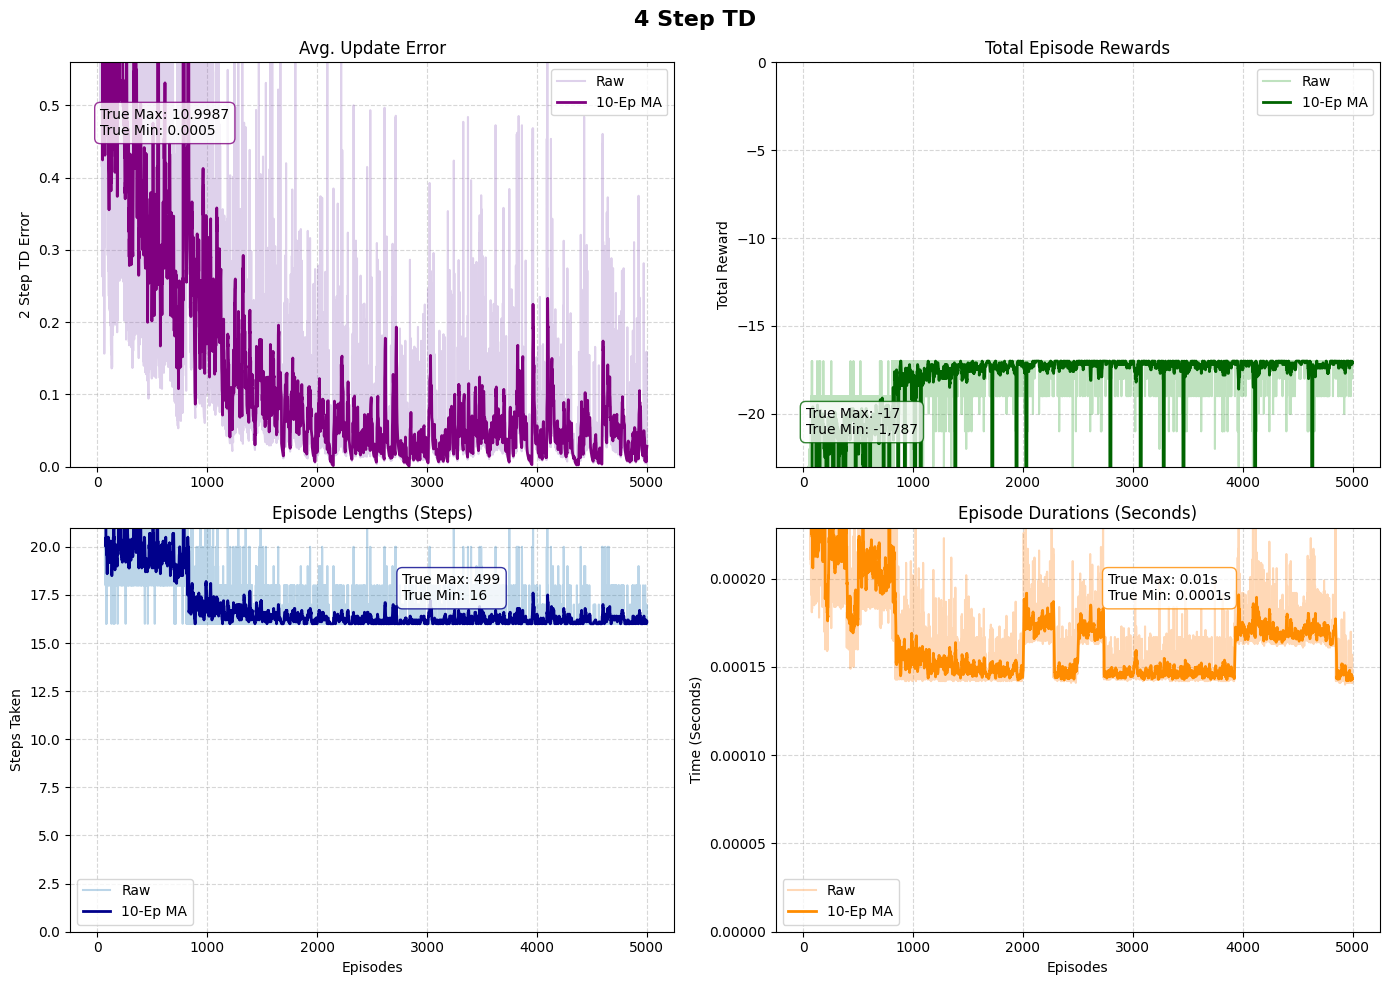

In [11]:
plot_smooth_graphs(
    episode_avg_td_error,
    episode_rewards=episode_rewards,
    episode_durations=episode_durations,
    episode_lengths=episode_lengths,
    title=f"{N_step} Step TD",
    error_ylabel="2 Step TD Error"
)

## Off Policy Methods

An Off Policy RL method is any method which has a **Behavourial Policy** that is differnt from the **Target Policy** that the agent is trying to learn. Here the **Target Policy** is the one we will try to optimize to **Optimal Policy***.

As our agent gains experience and optimises its policy, we will have

$$
\pi_{target} \rightarrow \pi_{*}
$$


and 

$$
\pi_{target} \ne \pi_{behavior}
$$

or in short, 

$$
\pi_{tar} \ne \pi_{b}
$$

### Q-Learning

One very popular Offline method that is derived from TD Zero Equations is the Q Learning method. The Main difference is that the TD Target value selection Lets Look at the different TD Targets.


| Algorithm | Policy Type | TD Target Formula |
| :--- | :--- | :--- |
| **SARSA / TD(0)** | On-Policy | $R_{t+1} + \gamma Q(s_{t+1}, a_{t+1})$ |
| **Q-Learning** | Off-Policy | $R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a)$ |

In Q-learning, the $\max_{a}$ scans *all* possible actions $a$ in the next state, rather than looking at the sampled action $a_{t+1}$. This is the crucial difference. Because the sampling our equation for $a_{t+1}$ is 

For TD Zero
$$
a_{t+1} = \begin{cases} \text{arg max}_{a} Q(S_{t+1}, a) & \text{with probability } 1 - \epsilon \\ \text{a random action from } \mathcal{A} & \text{with probability } \epsilon \end{cases}
$$

as compared to the following eq. for Q Learning:
$$
a_{t+1} = \begin{cases} \text{arg max}_{a} Q(S_{t+1}, a) & \text{with probability } 1  \end{cases}
$$


#### Update Equation.
Everything remains the same and the update equation becomes:

$$Q(s, a) \leftarrow Q(s, a) + \alpha (R + \gamma \max_{a} Q(s_{t+1}, a) - Q(s, a))$$

Lets See how it'll look in code.

#### Code.
Copy paste the TD Zero and just change TD Target Rquations.

In [12]:
#Importing Libraries
import gymnasium as gym
import numpy as np
from datetime import datetime
from utils import *

# Constants and Hyperparameters
epsilon = 0.1
epsilon_decay_rate = 0.999
epsilon_min = 0.01

gamma = 0.9
alpha = 0.1
num_episodes = 5000
MAX_STEPS_PER_EPISODE = 500

seed = 42
rng = np.random.default_rng(seed)

env = gym.make("CliffWalking-v1", max_episode_steps=MAX_STEPS_PER_EPISODE)

action_space = np.arange(env.action_space.n)
observation_space = np.arange(env.observation_space.n)

q_table = np.zeros((len(observation_space), len(action_space)))
episode_lengths = []
episode_rewards = []
episode_durations = []
episode_avg_td_error = [] #Instead of MC Error, we will track the average TD error per episode

In [13]:
def choose_action(state, epsilon):
    if rng.random() < epsilon:
        return rng.choice(action_space)
    else:
        return np.argmax(q_table[state])


for episode in range(num_episodes):
    state, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    episode_reward = 0
    episode_data = [] # To store (state, action, reward, next_state) for TD error calculation
    start_time = datetime.now()

    epsilon = max(epsilon * epsilon_decay_rate, epsilon_min)

    action = choose_action(state, epsilon)
    td_errors_in_episode = [] # To track TD errors for the current episode

    while not (terminated or truncated):

        next_state, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        episode_data.append((state, action, reward, next_state))

        if (terminated or truncated):
            td_target = reward  
            next_action = None
        else:
            next_action = choose_action(next_state, epsilon)
            # -------------------- TD Target Calculation -------------------- # 
            td_target = reward + gamma * np.max(q_table[next_state])
            # --------------------------------------------------------------- #

        td_error = td_target - q_table[state][action]
        q_table[state, action] += alpha * td_error


        td_errors_in_episode.append(abs(td_error))

        state = next_state
        action = next_action


    end_time = datetime.now()
    episode_lengths.append(len(episode_data))
    episode_rewards.append(episode_reward)
    episode_durations.append((end_time - start_time).total_seconds())

    # Calculate average TD error for the episode
    avg_td_error = np.mean(td_errors_in_episode)
    episode_avg_td_error.append(avg_td_error)
    if (episode + 1) % 500 == 0:
        print(f"Episode {episode + 1}/{num_episodes} - Total Reward: {episode_reward}, Length: {len(episode_data)}, Duration: {(end_time - start_time).total_seconds():.2f}s, Avg TD Error: {avg_td_error:.4f}")



Episode 500/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 1000/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 1500/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 2000/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 2500/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 3000/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 3500/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 4000/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 4500/5000 - Total Reward: -15, Length: 15, Duration: 0.00s, Avg TD Error: 0.0044
Episode 5000/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000


#### Simulate & Analyse

In [14]:
policy = lambda state :np.argmax(q_table[state])

visualize_policy(policy_fn=policy)


 Starting Evaluation: RL Agent
Step=  1 | State=24 | Reward=  -1 | Total Reward=  -1 | Action=Up
Step=  2 | State=25 | Reward=  -1 | Total Reward=  -2 | Action=Right
Step=  3 | State=26 | Reward=  -1 | Total Reward=  -3 | Action=Right
Step=  4 | State=27 | Reward=  -1 | Total Reward=  -4 | Action=Right
Step=  5 | State=28 | Reward=  -1 | Total Reward=  -5 | Action=Right
Step=  6 | State=29 | Reward=  -1 | Total Reward=  -6 | Action=Right
Step=  7 | State=30 | Reward=  -1 | Total Reward=  -7 | Action=Right
Step=  8 | State=31 | Reward=  -1 | Total Reward=  -8 | Action=Right
Step=  9 | State=32 | Reward=  -1 | Total Reward=  -9 | Action=Right
Step= 10 | State=33 | Reward=  -1 | Total Reward= -10 | Action=Right
Step= 11 | State=34 | Reward=  -1 | Total Reward= -11 | Action=Right
Step= 12 | State=35 | Reward=  -1 | Total Reward= -12 | Action=Right
Step= 13 | State=47 | Reward=  -1 | Total Reward= -13 | Action=Down
------------------------------------------
Simulation ended.
  - Total Epis


Agent Learning Summary:
  - Final TD Error Convergence: 0.0000
  - Total Episodes: 5000
  - Best Episode Reward: -13
  - Worst Episode Reward: -1,787
  - Average Episode Length: 15.65
  - Average Episode Duration: 0.00
  - Convergence Status: Converged in 313 (Threshold: 0.001)


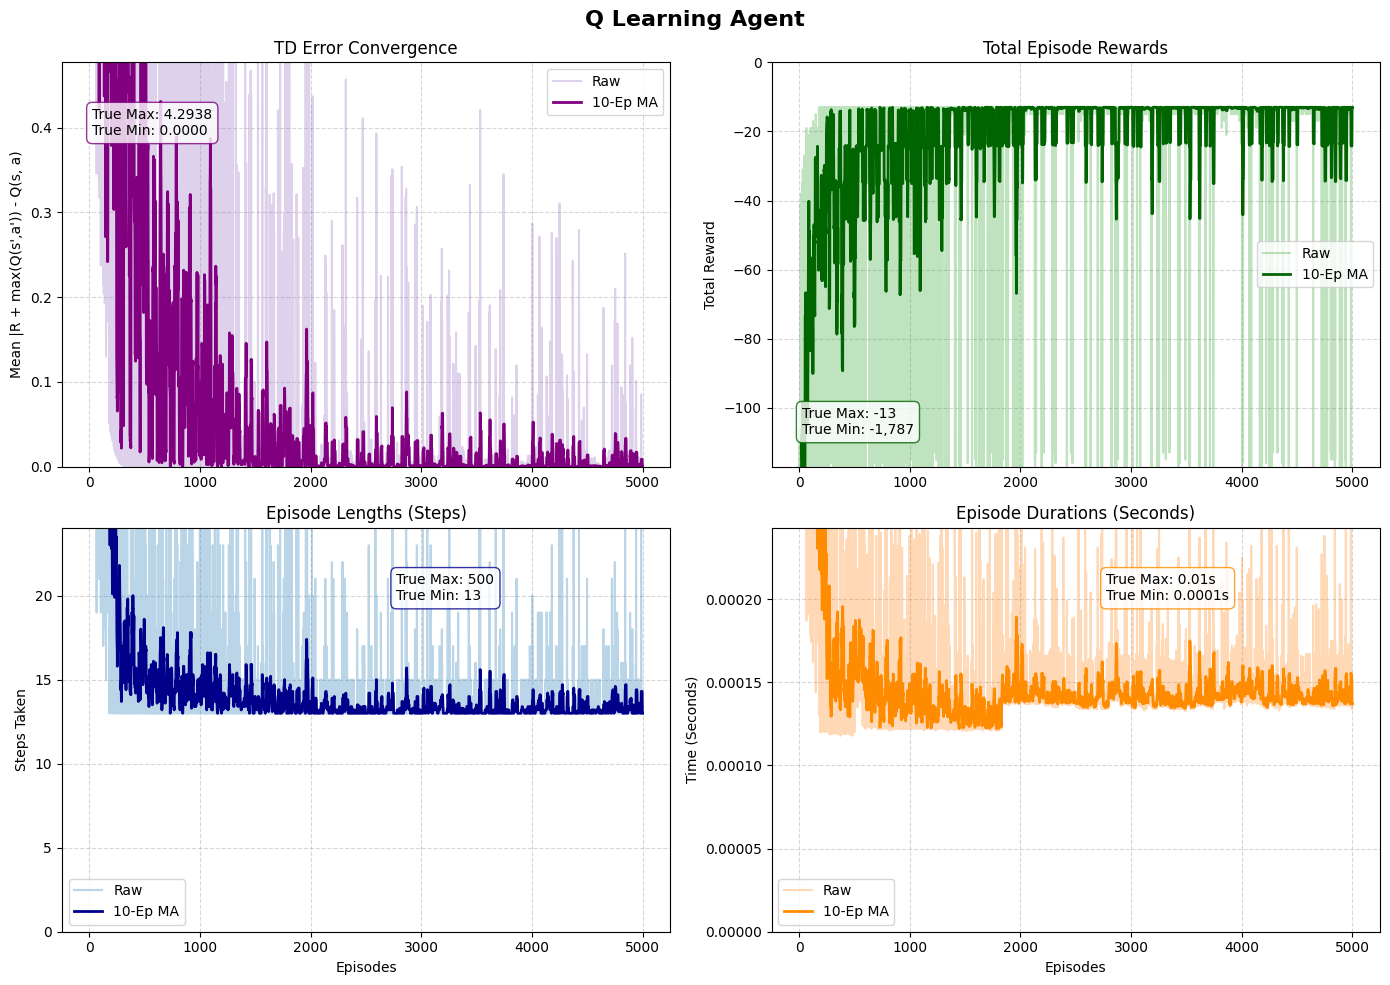

In [15]:
plot_smooth_graphs(
    errors=episode_avg_td_error,
    episode_rewards=episode_rewards,
    episode_durations=episode_durations,
    episode_lengths=episode_lengths,
    error_title="TD Error Convergence",
    error_ylabel="Mean |R + max(Q(s',a')) - Q(s, a)",
    title="Q Learning Agent"
)

#### Comments

We achieved fantastic performace, as compared to the TD Methods (Highest reward of -13) and the learning curve is incredible stable as well.

### Double Q-Learning

#### The Problem: Maximization Bias
Standard Q-learning has a bad habit of being over-optimistic. Because its TD target always uses a maximum ($\max_a$), it constantly chases the highest estimated reward.Since these estimates are noisy during training, the algorithm naturally overemphasizes positive noise. For example, if a state has three mediocre actions that all actually yield $0$ reward, random noise might make them look like $[-0.5, \mathbf{0.2}, -0.1]$ instead of *[0.0, 0.0, 0.0]*. Q-learning blindly grabs that $0.2$, assuming it found a great move. This constant overestimation is called **maximization bias**, and it quickly pollutes the entire Q-table, leading to unstable training and terrible policies.

#### The Fix: Don't Let the Same Person Grade the Test
Double Q-learning fixes this by decoupling action selection from action evaluation.Instead of letting one Q-table choose the best action and decide how much it's worth, we use two independent tables ($Q_A$ and $Q_B$): Sometimes Table A picks what it **thinks is the best action**.Table B looks at that action and **provides an unbiased** realty check on its actual value. Because the two tables are updated on different steps, it is highly unlikely they will both look at the same bad action and overestimate it at the same time. This simple trick completely neutralizes the maximization bias.


#### What will Table A and B do?
Important point of confusion: Note that Table A and Table B both will sometimes perform picking and somtimes perform value providing. It happens with 50% probability at every step! Lets look at an example.

Say we roll a dice and decide **Table A** will perform action Selection. So It Will give us the best action from its table at state $s_{t+1}$,

$$
a_{t+1} = \max_{a} Q_{A}(s_{t+1}, a)
$$

Where $Q_{A}$ is the Q Table A. Then we will fetch the value of performing this action from table B.

$$
value =  Q_{B} (s, a_{t+1})
$$

Where $Q_{B}$ is the Q Table B. Then we will calculate the TD Target, TD Erorr and finally update the **Q Table A**.

The final Update Equation will be:
$$
Q_{A}(s_{t}, a_{t}) \leftarrow Q_{A}(s_{t}, a_{t}) + \alpha( R_{t} + \gamma * value - Q_{A}(s_{t}, a_{t}))
$$


What if choose **Table B**?
Then our action selection will from from table B. We will follow the aforementioned steps.

Step 1:
$$
a_{t+1} = \max_{a} Q_{B}(s_{t+1}, a)
$$

Step 2: Then fetch value from Table A
$$
value =  Q_{A} (s, a_{t+1})
$$

Step 3: Update Table B
$$
Q_{B}(s_{t}, a_{t}) \leftarrow Q_{B}(s_{t}, a_{t}) + \alpha( R_{t} + \gamma * value - Q_{B}(s_{t}, a_{t}))
$$


#### Code
The code will essentially be identical to the Q learning method, except we have two q_tables, q_table_a, and q_table_b. and the TD Target Equations are different.

In [16]:
import gymnasium as gym
import numpy as np
from datetime import datetime
from utils import *

epsilon = 0.1
epsilon_decay_rate = 0.999
epsilon_min = 0.01

gamma = 0.9
alpha = 0.1
num_episodes = 5000
MAX_STEPS_PER_EPISODE = 500

seed = 42
rng = np.random.default_rng(seed)

env = gym.make("CliffWalking-v1", max_episode_steps=MAX_STEPS_PER_EPISODE)

action_space = np.arange(env.action_space.n)
observation_space = np.arange(env.observation_space.n)

# --------------------- Different Q Tables ---------------------- # 
q_table_A = np.zeros((len(observation_space), len(action_space)))
q_table_B = np.zeros((len(observation_space), len(action_space)))
# --------------------------------------------------------------- #

episode_lengths = []
episode_rewards = []
episode_durations = []
episode_avg_td_error = []

In [17]:
def choose_action_A(state, epsilon):
    if rng.random() < epsilon:
        return rng.choice(action_space)
    else:
        return np.argmax(q_table_A[state])
    
def choose_action_B(state, epsilon):
    if rng.random() < epsilon:
        return rng.choice(action_space)
    else:
        return np.argmax(q_table_B[state])


for episode in range(num_episodes):
    state, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    episode_reward = 0
    episode_data = [] # To store (state, action, reward, next_state) for TD error calculation
    start_time = datetime.now()

    epsilon = max(epsilon * epsilon_decay_rate, epsilon_min)
    policy_chosen = "A"
    td_errors_in_episode = [] # To track TD errors for the current episode

    while not (terminated or truncated):

        ## Chose Table for Update, A or B
        policy_chosen = "A" if rng.random() <= 0.5 else "B"

        if policy_chosen == "A":
            action = choose_action_A(state=state, epsilon=epsilon)
        if policy_chosen == "B":
            action = choose_action_B(state=state, epsilon=epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        episode_data.append((state, action, reward, next_state))

        if (terminated or truncated):
            td_target = reward  
            next_action = None
        else:
            # -------------------- TD Target Calculation -------------------- # 

            if policy_chosen == "A":
                best_action = np.argmax(q_table_A[next_state])
                td_target = reward + gamma * q_table_B[next_state, best_action]

            if policy_chosen == "B":
                best_action = np.argmax(q_table_B[next_state])
                td_target = reward + gamma * q_table_A[next_state, best_action]

            # --------------------------------------------------------------- #


        # ------------------------ Update Equation ------------------------ # 
        if policy_chosen == "A":
            td_error = td_target - q_table_A[state][action]
            q_table_A[state, action] += alpha * td_error
        
        if policy_chosen == "B":
            td_error = td_target - q_table_B[state][action]
            q_table_B[state, action] += alpha * td_error  
        # ----------------------------------------------------------------- #

        td_errors_in_episode.append(abs(td_error))
        state = next_state


    end_time = datetime.now()
    episode_lengths.append(len(episode_data))
    episode_rewards.append(episode_reward)
    episode_durations.append((end_time - start_time).total_seconds())

    # Calculate average TD error for the episode
    avg_td_error = np.mean(td_errors_in_episode)
    episode_avg_td_error.append(avg_td_error)
    if (episode + 1) % 500 == 0:
        print(f"Episode {episode + 1}/{num_episodes} - Total Reward: {episode_reward}, Length: {len(episode_data)}, Duration: {(end_time - start_time).total_seconds():.2f}s, Avg TD Error: {avg_td_error:.4f}")


Episode 500/5000 - Total Reward: -19, Length: 19, Duration: 0.00s, Avg TD Error: 0.1561
Episode 1000/5000 - Total Reward: -118, Length: 19, Duration: 0.00s, Avg TD Error: 1.9939
Episode 1500/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 2000/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 2500/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 3000/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 3500/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 4000/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 4500/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000
Episode 5000/5000 - Total Reward: -13, Length: 13, Duration: 0.00s, Avg TD Error: 0.0000



Agent Learning Summary:
  - Final TD Error Convergence: 0.0000
  - Total Episodes: 5000
  - Best Episode Reward: -13
  - Worst Episode Reward: -2,084
  - Average Episode Length: 17.22
  - Average Episode Duration: 0.00
  - Convergence Status: Converged in 600 (Threshold: 0.001)


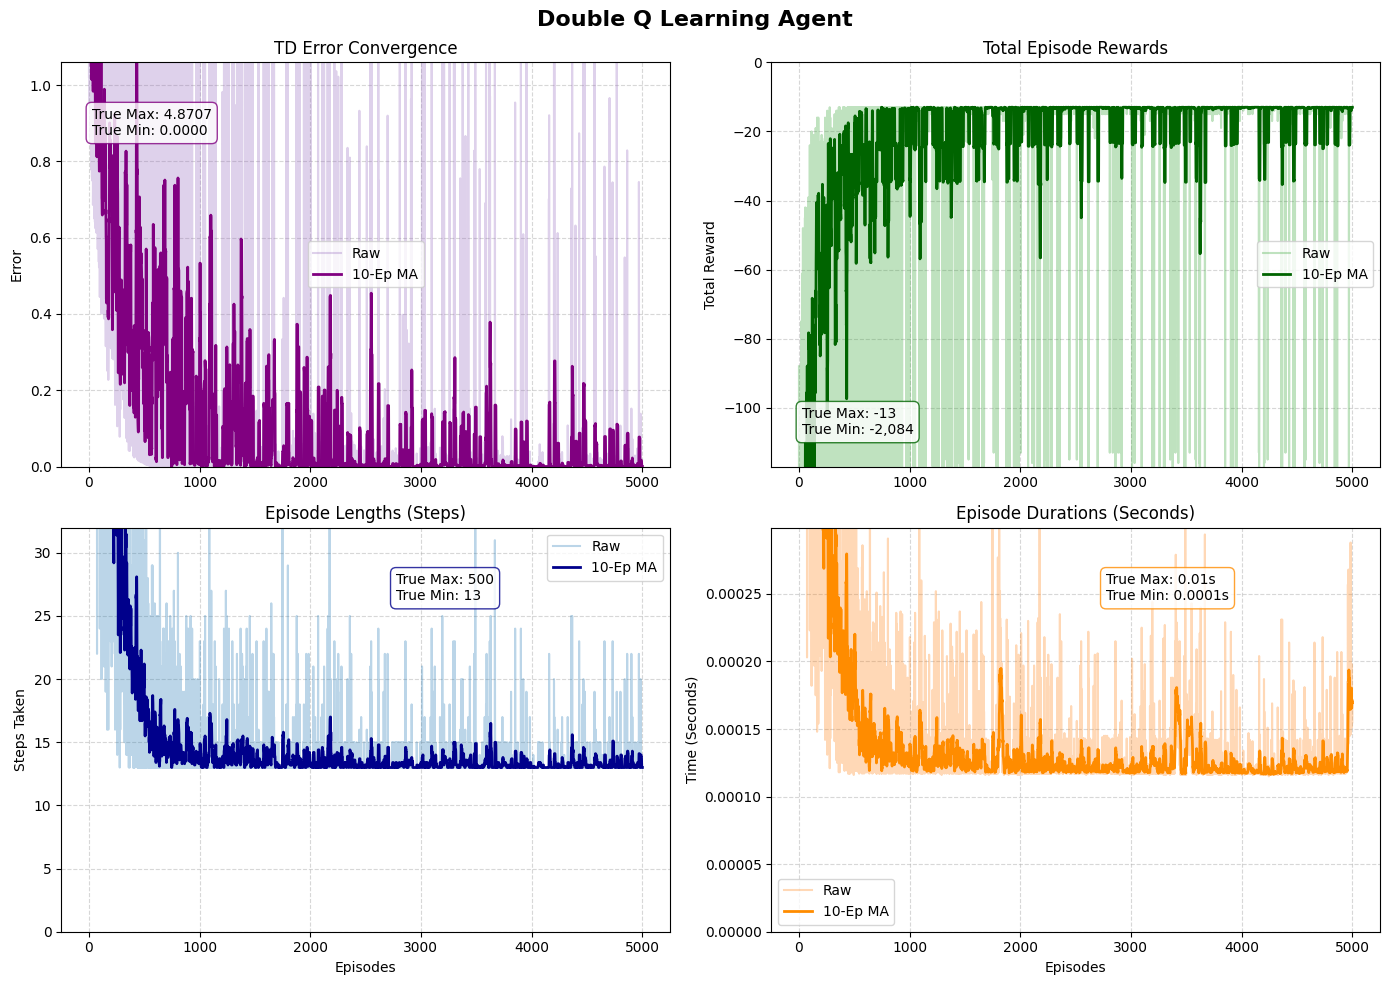

In [18]:
plot_smooth_graphs(
    errors=episode_avg_td_error,
    episode_rewards=episode_rewards,
    episode_durations=episode_durations,
    episode_lengths=episode_lengths,
    error_title="TD Error Convergence",
    error_ylabel="Error",
    title="Double Q Learning Agent"
)

#### Comment
Our Agent found the best route even faster, and the convergence was more stable - this is a direct result of neuralising the Maximization Bias